<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/10_tensorflow_keras_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TensorFlow & Keras Basics

In this notebook, we explore the fundamentals of TensorFlow and Keras, the most popular deep learning framework.

After implementing a neural network manually, we now learn how TensorFlow automates the entire training process.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
scalar = tf.constant(10)

print(scalar)

tf.Tensor(10, shape=(), dtype=int32)


In [4]:
print("Rank:", tf.rank(scalar))
print("Shape:", scalar.shape)

Rank: tf.Tensor(0, shape=(), dtype=int32)
Shape: ()


In [5]:
vector = tf.constant([1,2,3,4,5])

print(vector)

print("Rank:", tf.rank(vector))

print("Shape:", vector.shape)

tf.Tensor([1 2 3 4 5], shape=(5,), dtype=int32)
Rank: tf.Tensor(1, shape=(), dtype=int32)
Shape: (5,)


In [6]:
matrix = tf.constant([
    [1,2],
    [3,4],
    [5,6]
])

print(matrix)

print("Rank:", tf.rank(matrix))

print("Shape:", matrix.shape)

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)
Rank: tf.Tensor(2, shape=(), dtype=int32)
Shape: (3, 2)


In [7]:
tensor3d = tf.constant([
    [
        [1,2],
        [3,4]
    ],
    [
        [5,6],
        [7,8]
    ]
])

print(tensor3d)

print("Rank:", tf.rank(tensor3d))

print("Shape:", tensor3d.shape)

tf.Tensor(
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]], shape=(2, 2, 2), dtype=int32)
Rank: tf.Tensor(3, shape=(), dtype=int32)
Shape: (2, 2, 2)


In [8]:
A = tf.constant([[1,2],[3,4]])

B = tf.constant([[5,6],[7,8]])

print(tf.add(A,B))

tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)


In [9]:
print(tf.multiply(A,B))

tf.Tensor(
[[ 5 12]
 [21 32]], shape=(2, 2), dtype=int32)


In [10]:
print(tf.matmul(A,B))

tf.Tensor(
[[19 22]
 [43 50]], shape=(2, 2), dtype=int32)


In [11]:
tensor = tf.constant([
    1,2,3,4,5,6
])

reshaped = tf.reshape(
    tensor,
    (2,3)
)

print(reshaped)

tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)


In [12]:
variable = tf.Variable([1.0,2.0])

print(variable)

<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([1., 2.], dtype=float32)>


In [13]:
variable.assign([10,20])

print(variable)

<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([10., 20.], dtype=float32)>


In [14]:
random_tensor = tf.random.normal(
    shape=(3,3)
)

print(random_tensor)

tf.Tensor(
[[-0.97225356 -1.0691559  -1.8713423 ]
 [ 1.0353734   0.16757345  0.82548976]
 [ 1.147152    0.60263467 -0.63237   ]], shape=(3, 3), dtype=float32)


In [15]:
zeros = tf.zeros((3,3))

print(zeros)

tf.Tensor(
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]], shape=(3, 3), dtype=float32)


In [16]:
ones = tf.ones((3,3))

print(ones)

tf.Tensor(
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]], shape=(3, 3), dtype=float32)


In [17]:
model = tf.keras.Sequential()

In [18]:
model.add(
    tf.keras.layers.Dense(
        4,
        activation="relu"
    )
)

In [19]:
model.add(
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
)

In [20]:
model.build(
    input_shape=(None,2)
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
print(model.layers)

[<Dense name=dense, built=True>, <Dense name=dense_1, built=True>]


In [23]:
for layer in model.layers:

    print(layer.name)

dense
dense_1


In [24]:
print(
    model.count_params()
)

17


In [25]:
weights = model.get_weights()

for weight in weights:

    print(weight)

[[ 0.39939618 -0.5288      0.458714   -0.14348626]
 [-0.27378893 -0.50830626  0.6884346  -0.67002606]]
[0. 0. 0. 0.]
[[-1.0072346 ]
 [-0.8521144 ]
 [ 0.58878124]
 [-0.7163906 ]]
[0.]


In [26]:
comparison = {

    "Manual Implementation":[

        "Initialize Weights",

        "Forward Propagation",

        "Compute Loss",

        "Backpropagation",

        "Gradient Descent"

    ],

    "TensorFlow":[

        "Automatic",

        "Automatic",

        "Automatic",

        "Automatic",

        "Automatic"

    ]

}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Manual Implementation,TensorFlow
0,Initialize Weights,Automatic
1,Forward Propagation,Automatic
2,Compute Loss,Automatic
3,Backpropagation,Automatic
4,Gradient Descent,Automatic


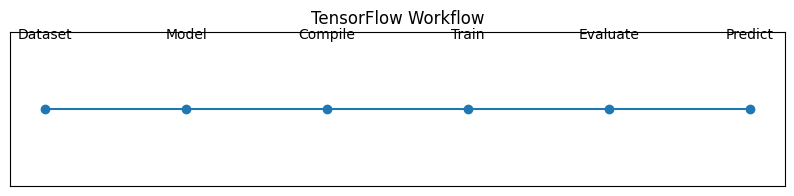

In [27]:
steps = [

    "Dataset",

    "Model",

    "Compile",

    "Train",

    "Evaluate",

    "Predict"

]

plt.figure(figsize=(10,2))

plt.plot(
    range(len(steps)),
    [1]*len(steps),
    marker="o"
)

for i,step in enumerate(steps):

    plt.text(
        i,
        1.05,
        step,
        ha="center"
    )

plt.xticks([])

plt.yticks([])

plt.title("TensorFlow Workflow")

plt.show()